Nom : El jattioui
Prenom : Maryame
Master : GLCC

Époque 0: Perte (Loss) = 0.6931
Époque 200: Perte (Loss) = 0.3080
Époque 400: Perte (Loss) = 0.2268
Époque 600: Perte (Loss) = 0.1888
Époque 800: Perte (Loss) = 0.1661


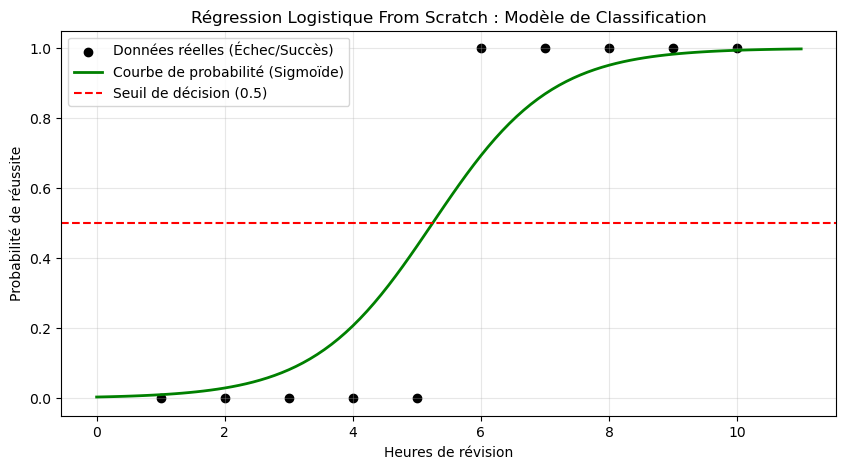

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. PRÉPARATION DES DONNÉES
# =================================================================
# X : Heures de révision (Variable explicative)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
# y : Résultat (0 = Échec, 1 = Succès). C'est une classification binaire.
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# =================================================================
# 2. FONCTIONS MATHÉMATIQUES DU MODÈLE
# =================================================================

def sigmoid(z):
    """
    La fonction Sigmoïde est le cœur de la régression logistique.
    Elle prend n'importe quelle valeur réelle (z) et la transforme 
    en une valeur comprise entre 0 et 1.
    C'est ce qui nous permet d'interpréter le résultat comme une PROBABILITÉ.
    """
    return 1 / (1 + np.exp(-z))

def compute_loss(y_true, y_pred):
    """
    Log Loss (ou Binary Cross-Entropy). 
    Contrairement à la régression linéaire, on n'utilise pas l'erreur au carré.
    On utilise le logarithme pour pénaliser fortement les mauvaises prédictions 
    qui sont faites avec une grande confiance.
    """
    epsilon = 1e-15 # Petite valeur pour éviter log(0) qui est indéfini
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

# =================================================================
# 3. ENTRAÎNEMENT PAR DESCENTE DE GRADIENT
# =================================================================
def fit_logistic(X, y, lr=0.1, epochs=1000):
    # Ajout d'une colonne de 1 pour le Biais (Intercept)
    X_b = np.c_[np.ones((len(X), 1)), X]
    # Initialisation des poids (weights) à zéro. 
    # weights[0] est le biais, weights[1] est l'importance de l'heure de révision.
    weights = np.zeros(X_b.shape[1]) 
    
    for epoch in range(epochs):
        # Étape 1 : Forward Pass (Prédiction)
        # On calcule le score z (linéaire) puis on applique la sigmoïde
        z = np.dot(X_b, weights)
        y_pred = sigmoid(z)
        
        # Étape 2 : Calcul du Gradient (Backpropagation simplifiée)
        # Le gradient indique dans quelle direction modifier les poids pour réduire l'erreur.
        # C'est la différence entre la prédiction et la réalité, projetée sur les données X.
        gradient = np.dot(X_b.T, (y_pred - y)) / len(y)
        
        # Étape 3 : Mise à jour des poids (Update rule)
        # On soustrait une petite partie du gradient (Learning Rate) aux poids actuels.
        weights -= lr * gradient
        
        # Affichage du suivi de l'apprentissage
        if epoch % 200 == 0:
            loss = compute_loss(y, y_pred)
            print(f"Époque {epoch}: Perte (Loss) = {loss:.4f}")
            
    return weights

# Lancement de l'apprentissage
weights = fit_logistic(X, y)

# =================================================================
# 4. PRÉDICTION ET VISUALISATION
# =================================================================
# On crée un jeu de test de 0 à 11 heures pour tracer une courbe lisse
X_test = np.linspace(0, 11, 100).reshape(-1, 1)
X_test_b = np.c_[np.ones((100, 1)), X_test]
y_prob = sigmoid(np.dot(X_test_b, weights))

plt.figure(figsize=(10, 5))
# Affichage des points réels (soit 0, soit 1)
plt.scatter(X, y, color='black', label='Données réelles (Échec/Succès)')

# Affichage de la courbe de probabilité
plt.plot(X_test, y_prob, color='green', linewidth=2, label='Courbe de probabilité (Sigmoïde)')

# Ligne de décision (Threshold)
# En général, si proba > 0.5, on classe en "Admis".
plt.axhline(y=0.5, color='red', linestyle='--', label='Seuil de décision (0.5)')

plt.title('Régression Logistique From Scratch : Modèle de Classification')
plt.xlabel('Heures de révision')
plt.ylabel('Probabilité de réussite')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()